In [13]:
import matplotlib.pylab as plt
import numpy as np
import matplotlib.animation as animation

def TL(t):
  T = 10.0
  return T

def TR(t):
  T = 10.0 + 2.5*np.sin(4*np.pi*t)
  return T

def CondicionInicial(x):

  caso = 1
  if caso == 1:
    T = 10.0

  return T

def main():

  xL = 0.0
  xR = 1.0

  N = 20
  dx = (xR-xL)/(N-1)

  T    = np.zeros(N)
  Tnew = np.zeros(N)
  x    = np.linspace(xL,xR,N)

  time = 0.0
  tfin = 1.0

  k = 1.0
  rho = 10.0
  Cp = 1.0
  alpha = k/(rho*Cp)

  CFL = 0.450

  it = 0

  dt = CFL * dx**2/alpha
  print('dt = ',dt)

  for i in range(N):
    T[i] = CondicionInicial(x[i])

  # List to store temperature profiles for animation
  T_profiles = []
  times = []

  # Store initial state
  T_profiles.append(T.copy())
  times.append(time)

  while time < tfin:
    if time + dt > tfin:
      dt = tfin - time

    for i in range(N):
      if i == 0:
        Tnew[i] = TL(time)
      elif i == N-1:
        Tnew[i] = TR(time)
      else:
        Tnew[i] = T[i] + alpha * dt / (dx**2) * (T[i+1] - 2*T[i] + T[i-1])

    T = Tnew.copy()
    time = time + dt
    it = it + 1

    T_profiles.append(T.copy())
    times.append(time)

  fig, ax = plt.subplots(figsize=(10, 6))
  line, = ax.plot(x, T_profiles[0])
  ax.set_xlabel('x')
  ax.set_ylabel('T °C')
  ax.set_ylim(5.0, 15.0)
  ax.set_title('Evolución temporal de la temperatura')
  ax.grid(True, linestyle='--', alpha=0.7)

  def update(frame):
    line.set_ydata(T_profiles[frame])
    ax.set_title(f'Evolución temporal de la temperatura | Time = {times[frame]:.4f} s')
    return line,

  ani = animation.FuncAnimation(
      fig,
      update,
      frames=len(T_profiles),
      interval=100,  # Milliseconds per frame
      blit=True
  )

  # To save the animation, you will need ffmpeg or imagemagick installed
  # For Colab, usually imagemagick is available for GIF.
  # If you prefer MP4, you might need to install ffmpeg: !apt-get update && apt-get install ffmpeg
  ani.save('difusion_calor.gif', writer='pillow', fps=10)
  plt.close(fig) # Close the plot to prevent it from showing before the GIF is generated
  print('Animation saved as difusion_calor.gif')

  return x,T,time,it

x,T,time,it = main()


dt =  0.012465373961218836
Animation saved as difusion_calor.gif


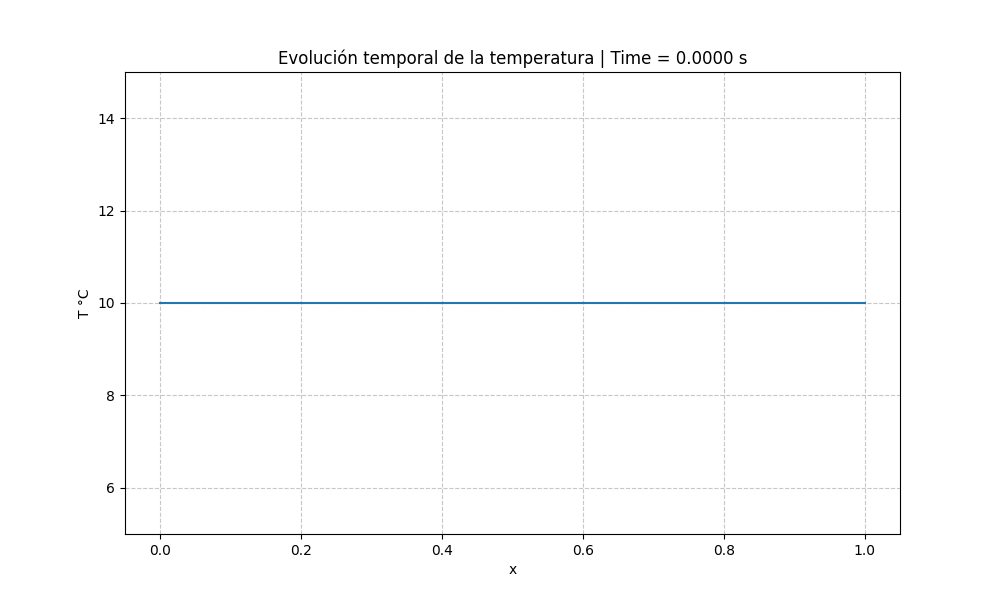

In [14]:
from IPython.display import Image
Image(open('difusion_calor.gif','rb').read())

Text(0.5, 1.0, ' Time = 1.0000 s')

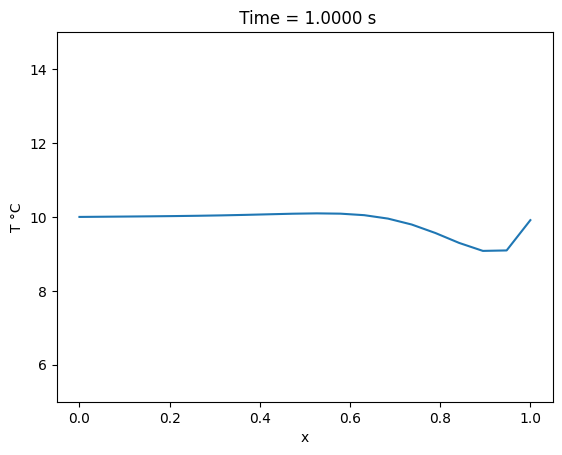

In [15]:
fig = plt.figure('Solución final')
plt.clf()
plt.plot(x,T)
plt.ylim(5.0,15.0)
plt.xlabel('x')
plt.ylabel('T °C')
plt.title(' Time = {:0.4f} s'.format(time))